### 0. Content page

1. Load packages and data
2. Helper functions
3. Rebuild long / short / net returns
4. Core performance table
5. Cumulative performance plot: Long / Short / Net
6. Drawdown plot
7. Return histogram
8. Long vs short correlation and descriptive stats
9. Signal diagnostics: E/P and P/B
10. Universe size over time
11. Portfolio breadth over time
12. Long vs short composition
13. Benchmark comparison vs S&P 500
14. Turnover
15. A compact text summary cell for every model

### 1. Load packages and data

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

In [2]:
RESULT_DIR = "../tables/carhart4_full_price_available_universe_modular"

In [3]:
portfolio_returns = pd.read_csv(f"{RESULT_DIR}/portfolio_returns.csv")
asset_returns = pd.read_csv(f"{RESULT_DIR}/asset_returns.csv")
weights_at_E = pd.read_csv(f"{RESULT_DIR}/weights_at_E.csv")
signals_at_T = pd.read_csv(f"{RESULT_DIR}/signals_at_T.csv")

# optional
try:
    portfolio_membership_at_T = pd.read_csv(f"{RESULT_DIR}/portfolio_membership_at_T.csv")
except FileNotFoundError:
    portfolio_membership_at_T = None

In [4]:
# parse dates
for c in ["signal_date", "execution_date", "next_execution_date"]:
    if c in portfolio_returns.columns:
        portfolio_returns[c] = pd.to_datetime(portfolio_returns[c])

for c in ["signal_date", "execution_date", "next_execution_date", "actual_exit_date"]:
    if c in asset_returns.columns:
        asset_returns[c] = pd.to_datetime(asset_returns[c])

for c in ["signal_date", "execution_date"]:
    if c in weights_at_E.columns:
        weights_at_E[c] = pd.to_datetime(weights_at_E[c])

if "signal_date" in signals_at_T.columns:
    signals_at_T["signal_date"] = pd.to_datetime(signals_at_T["signal_date"])

if portfolio_membership_at_T is not None:
    for c in ["signal_date", "execution_date"]:
        if c in portfolio_membership_at_T.columns:
            portfolio_membership_at_T[c] = pd.to_datetime(portfolio_membership_at_T[c])

In [5]:
print("portfolio_returns:", portfolio_returns.shape)
print("asset_returns:", asset_returns.shape)
print("weights_at_E:", weights_at_E.shape)
print("signals_at_T:", signals_at_T.shape)
if portfolio_membership_at_T is not None:
    print("portfolio_membership_at_T:", portfolio_membership_at_T.shape)

portfolio_returns: (310, 4)
asset_returns: (229989, 11)
weights_at_E: (229989, 22)
signals_at_T: (575724, 18)
portfolio_membership_at_T: (229989, 21)


### 2. Helper functions

In [6]:
def annualized_sharpe(monthly_returns: pd.Series) -> float:
    monthly_returns = monthly_returns.dropna()
    if monthly_returns.std() == 0:
        return np.nan
    return monthly_returns.mean() / monthly_returns.std() * np.sqrt(12)

def max_drawdown(return_series: pd.Series) -> float:
    cum = (1 + return_series.fillna(0)).cumprod()
    roll_max = cum.cummax()
    drawdown = cum / roll_max - 1
    return drawdown.min()

def performance_summary(return_series: pd.Series) -> pd.Series:
    return pd.Series({
        "mean_monthly": return_series.mean(),
        "vol_monthly": return_series.std(),
        "ann_sharpe": annualized_sharpe(return_series),
        "positive_month_pct": (return_series > 0).mean(),
        "max_drawdown": max_drawdown(return_series),
    })

### 3. Rebuild long / short / net returns

In [7]:
ls_monthly = (
    asset_returns
    .groupby(["signal_date", "execution_date", "next_execution_date", "side"], as_index=False)["weighted_return"]
    .sum()
    .pivot(
        index=["signal_date", "execution_date", "next_execution_date"],
        columns="side",
        values="weighted_return"
    )
    .reset_index()
)

ls_monthly.columns.name = None

for col in ["long", "short"]:
    if col not in ls_monthly.columns:
        ls_monthly[col] = 0.0

ls_monthly = ls_monthly.rename(columns={
    "long": "long_return",
    "short": "short_return"
})

ls_monthly["portfolio_return_rebuilt"] = (
    ls_monthly["long_return"] + ls_monthly["short_return"]
)

ls_monthly.head()

,signal_date,execution_date,next_execution_date,long_return,short_return,portfolio_return_rebuilt
0,2000-02-29,2000-03-01,2000-04-03,0.014982,-0.017300,-0.002317
1,2000-03-31,2000-04-03,2000-05-01,0.004224,0.017843,0.022067
2,2000-04-28,2000-05-01,2000-06-01,-0.003875,0.038704,0.034829
3,2000-05-31,2000-06-01,2000-07-03,-0.001720,-0.061412,-0.063132
4,2000-06-30,2000-07-03,2000-08-01,0.000121,0.022417,0.022538


In [8]:
# optional consistency check against saved portfolio_returns.csv
check = portfolio_returns.merge(
    ls_monthly,
    on=["signal_date", "execution_date", "next_execution_date"],
    how="inner"
)

check["diff"] = check["portfolio_return"] - check["portfolio_return_rebuilt"]

print("max abs diff:", check["diff"].abs().max())
print("nonzero diff rows:", (check["diff"].abs() > 1e-12).sum())

max abs diff: 1.5182299861749016e-14
nonzero diff rows: 0


### 4. Core performance table

In [9]:
summary_table = pd.DataFrame({
    "long_leg": performance_summary(ls_monthly["long_return"]),
    "short_leg": performance_summary(ls_monthly["short_return"]),
    "net_portfolio": performance_summary(ls_monthly["portfolio_return_rebuilt"]),
}).T

summary_table

,mean_monthly,vol_monthly,ann_sharpe,positive_month_pct,max_drawdown
long_leg,0.005472,0.027745,0.683259,0.603226,-0.304288
short_leg,-0.003429,0.034175,-0.347559,0.435484,-0.793893
net_portfolio,0.002044,0.019547,0.362171,0.535484,-0.278919


### 5. Cumulative performance plot: Long / Short / Net

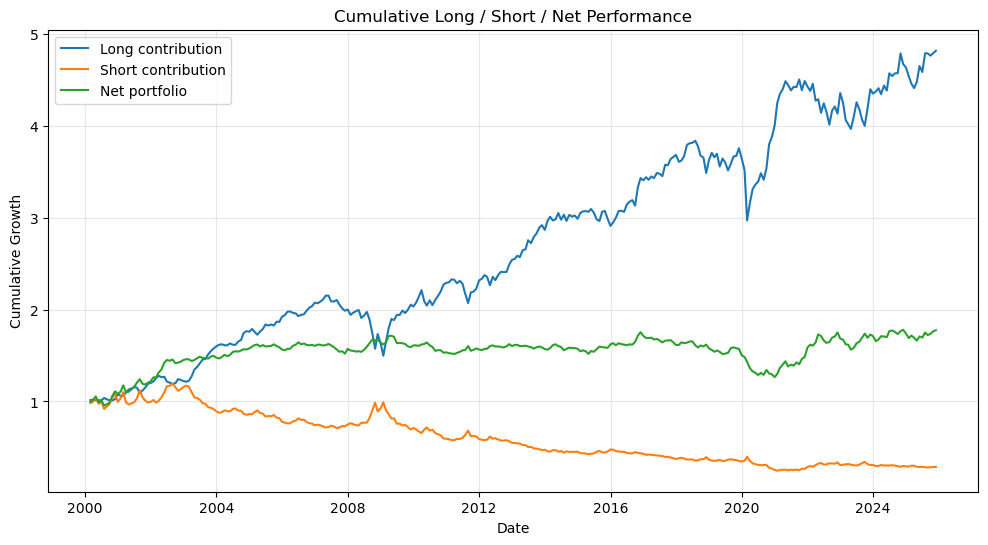

In [10]:
plot_df = ls_monthly.sort_values("signal_date").copy()

plot_df["cum_long"] = (1 + plot_df["long_return"]).cumprod()
plot_df["cum_short"] = (1 + plot_df["short_return"]).cumprod()
plot_df["cum_net"] = (1 + plot_df["portfolio_return_rebuilt"]).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(plot_df["signal_date"], plot_df["cum_long"], label="Long contribution")
plt.plot(plot_df["signal_date"], plot_df["cum_short"], label="Short contribution")
plt.plot(plot_df["signal_date"], plot_df["cum_net"], label="Net portfolio")
plt.title("Cumulative Long / Short / Net Performance")
plt.xlabel("Date")
plt.ylabel("Cumulative Growth")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 6. Drawdown plot

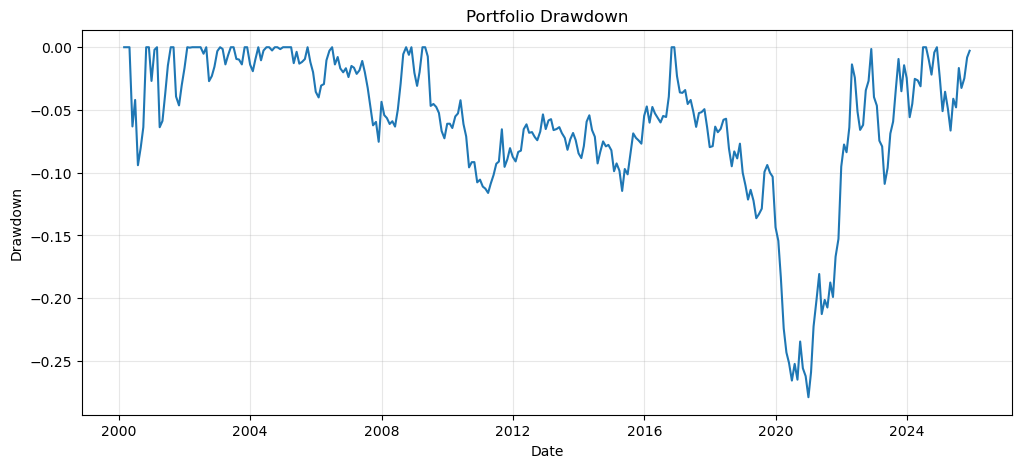

In [11]:
drawdown_df = plot_df[["signal_date", "portfolio_return_rebuilt"]].copy()
drawdown_df["cum"] = (1 + drawdown_df["portfolio_return_rebuilt"]).cumprod()
drawdown_df["roll_max"] = drawdown_df["cum"].cummax()
drawdown_df["drawdown"] = drawdown_df["cum"] / drawdown_df["roll_max"] - 1

plt.figure(figsize=(12, 5))
plt.plot(drawdown_df["signal_date"], drawdown_df["drawdown"])
plt.title("Portfolio Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.grid(True, alpha=0.3)
plt.show()

### 7. Return histogram

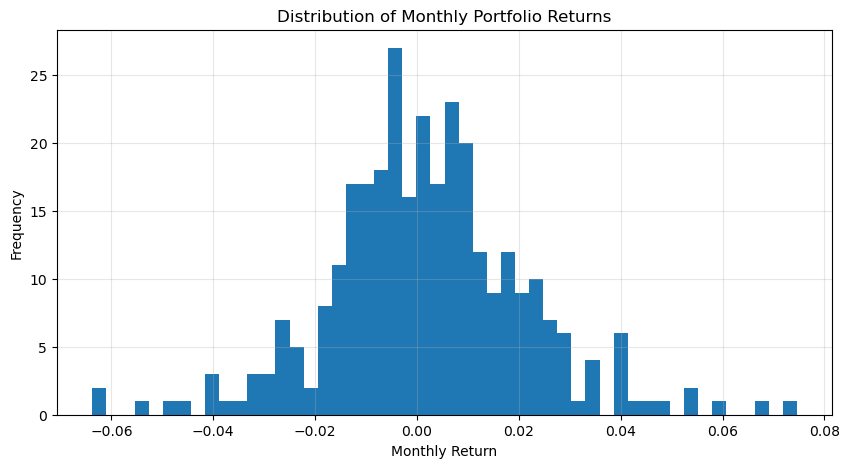

In [12]:
plt.figure(figsize=(10, 5))
plt.hist(ls_monthly["portfolio_return_rebuilt"], bins=50)
plt.title("Distribution of Monthly Portfolio Returns")
plt.xlabel("Monthly Return")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.3)
plt.show()

### 8. Long vs short correlation and descriptive stats

In [13]:
corr_ls = ls_monthly["long_return"].corr(ls_monthly["short_return"])
print("Correlation between long and short contributions:", corr_ls)

Correlation between long and short contributions: -0.8203299432892076


In [14]:
ls_monthly[["long_return", "short_return", "portfolio_return_rebuilt"]].describe()

,long_return,short_return,portfolio_return_rebuilt
count,310.000000,310.000000,310.000000
mean,0.005472,-0.003429,0.002044
std,0.027745,0.034175,0.019547
min,-0.155292,-0.115495,-0.063758
25%,-0.010463,-0.023427,-0.009437
50%,0.006235,-0.004477,0.001276
75%,0.021545,0.014315,0.012593
max,0.102413,0.120944,0.074577


In [15]:
# gross-normalized leg returns assuming 0.5 gross long / 0.5 gross short
ls_monthly["long_book_raw_return"] = ls_monthly["long_return"] / 0.5
ls_monthly["short_book_pnl_per_gross"] = ls_monthly["short_return"] / 0.5

ls_monthly[[
    "long_return",
    "short_return",
    "long_book_raw_return",
    "short_book_pnl_per_gross"
]].describe()

,long_return,short_return,long_book_raw_return,short_book_pnl_per_gross
count,310.000000,310.000000,310.000000,310.000000
mean,0.005472,-0.003429,0.010945,-0.006858
std,0.027745,0.034175,0.055490,0.068350
min,-0.155292,-0.115495,-0.310583,-0.230990
25%,-0.010463,-0.023427,-0.020926,-0.046854
50%,0.006235,-0.004477,0.012469,-0.008953
75%,0.021545,0.014315,0.043091,0.028630
max,0.102413,0.120944,0.204826,0.241887


### 9. Signal diagnostics: E/P and P/B

In [16]:
weights_at_E["ep"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])

count    229989.000000
mean          0.800455
std         118.238032
min       -2700.816236
1%           -1.042612
5%           -0.190621
50%           0.042546
95%           0.219126
99%           1.397941
max       32614.522438
Name: ep, dtype: float64

In [17]:
weights_at_E["pb"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])

count    2.299890e+05
mean     1.948387e+03
std      1.941085e+05
min      1.030126e-06
1%       7.985605e-02
5%       5.486480e-01
50%      2.232721e+00
95%      4.241557e+01
99%      4.498714e+02
max      4.930604e+07
Name: pb, dtype: float64

In [18]:
weights_at_E["mom_1m"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])

count    229989.000000
mean          0.001617
std           0.171046
min          -4.406742
1%           -0.376545
5%           -0.217632
50%           0.000000
95%           0.212901
99%           0.437537
max          15.666666
Name: mom_1m, dtype: float64

In [19]:
weights_at_E["ep"].sort_values(ascending=False).head(10)

181112    32614.522438
182515    32456.199460
183530    32330.643563
43734       564.118655
228977      495.557110
226884      495.557110
227739      495.557110
103748      463.248616
44276       451.312562
106189      448.368642
Name: ep, dtype: float64

In [20]:
weights_at_E["pb"].sort_values(ascending=False).head(10)

159696    4.930604e+07
137308    4.324302e+07
136624    3.773980e+07
158813    2.093930e+07
157917    1.845908e+07
88304     1.755752e+07
87602     1.696346e+07
86682     1.642209e+07
85285     1.406745e+07
84617     1.257912e+07
Name: pb, dtype: float64

In [21]:
weights_at_E["mom_1m"].sort_values(ascending=False).head(10)

160427    15.666666
215216    15.057693
208112    12.250000
159250    11.651163
227806    11.301676
218379    10.000000
179991     8.813084
150183     7.558823
131037     6.702500
71112      6.000000
Name: mom_1m, dtype: float64

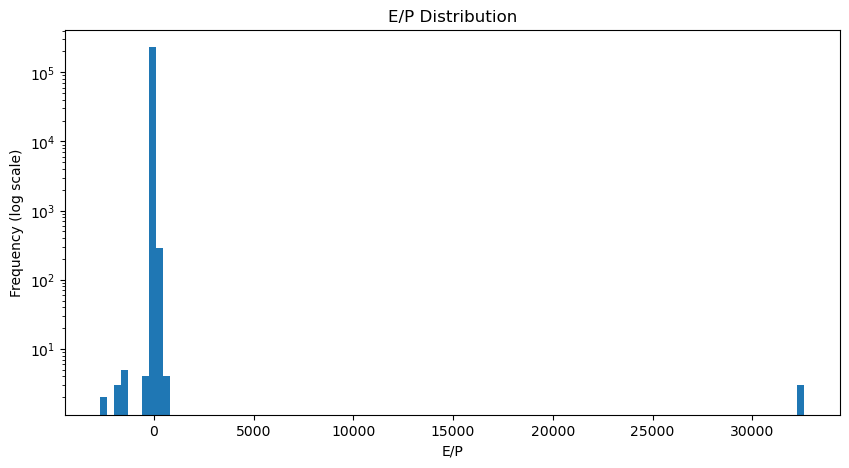

In [22]:
plt.figure(figsize=(10, 5))
plt.hist(weights_at_E["ep"], bins=100)
plt.yscale("log")
plt.title("E/P Distribution")
plt.xlabel("E/P")
plt.ylabel("Frequency (log scale)")
plt.show()

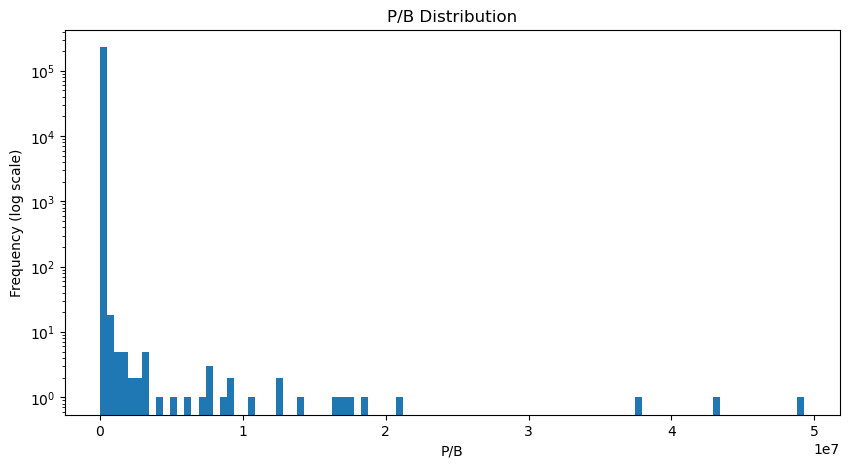

In [23]:
plt.figure(figsize=(10, 5))
plt.hist(weights_at_E["pb"], bins=100)
plt.yscale("log")
plt.title("P/B Distribution")
plt.xlabel("P/B")
plt.ylabel("Frequency (log scale)")
plt.show()

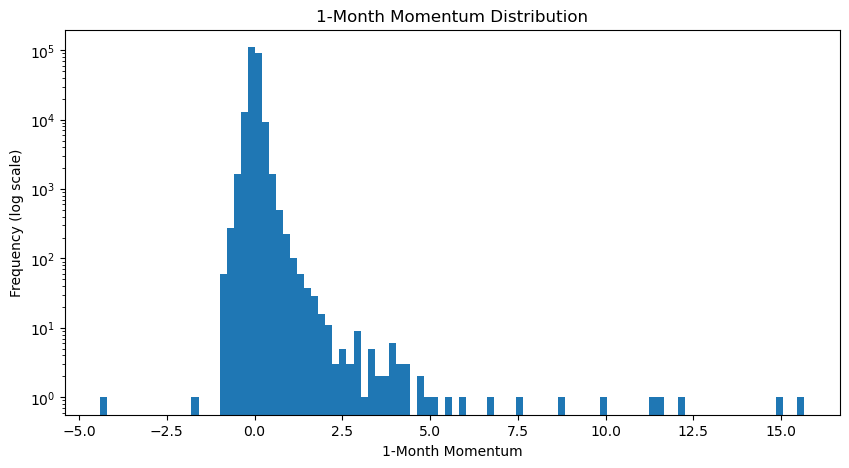

In [24]:
plt.figure(figsize=(10, 5))
plt.hist(weights_at_E["mom_1m"], bins=100)
plt.yscale("log")
plt.title("1-Month Momentum Distribution")
plt.xlabel("1-Month Momentum")
plt.ylabel("Frequency (log scale)")
plt.show()

### 10. Universe size over time

In [25]:
universe_size = (
    signals_at_T.groupby("signal_date")["ticker"]
    .nunique()
    .reset_index(name="n_universe")
)

universe_size.head()

,signal_date,n_universe
0,2000-02-29,755
1,2000-03-31,789
2,2000-04-28,794
3,2000-05-31,778
4,2000-06-30,785


In [26]:
universe_size["n_universe"].describe()

count     310.000000
mean     1857.174194
std       679.433094
min       755.000000
25%      1336.500000
50%      1694.000000
75%      2341.750000
max      3051.000000
Name: n_universe, dtype: float64

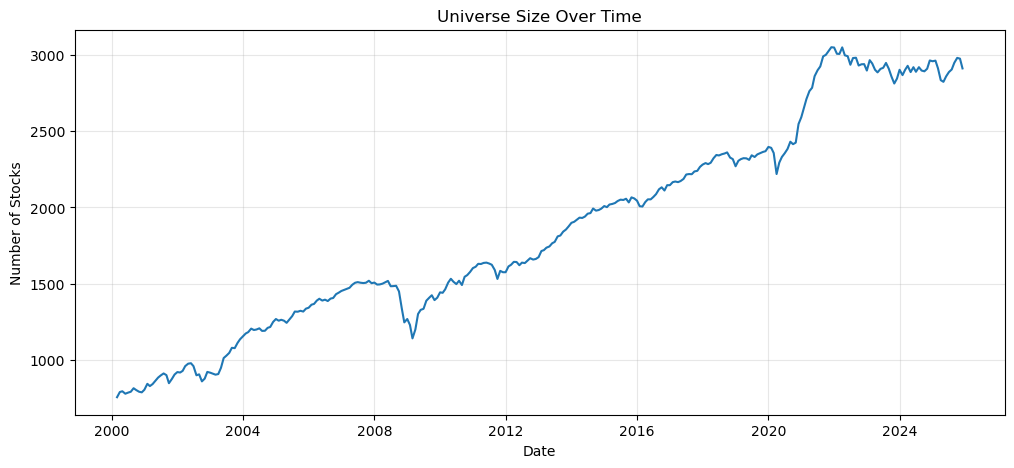

In [27]:
plt.figure(figsize=(12, 5))
plt.plot(universe_size["signal_date"], universe_size["n_universe"])
plt.title("Universe Size Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Stocks")
plt.grid(True, alpha=0.3)
plt.show()

### 11. Portfolio breadth over time

In [28]:
breadth = (
    asset_returns
    .groupby(["signal_date", "side"])["ticker"]
    .nunique()
    .unstack()
    .reset_index()
    .rename(columns={"long": "n_long", "short": "n_short"})
)

breadth.head()

side,signal_date,n_long,n_short
0,2000-02-29,151,151
1,2000-03-31,157,157
2,2000-04-28,158,158
3,2000-05-31,155,155
4,2000-06-30,157,157


In [29]:
breadth[["n_long", "n_short"]].describe()

side,n_long,n_short
count,310.000000,310.000000
mean,370.916129,370.983871
std,135.974796,135.892101
min,151.000000,151.000000
25%,267.000000,267.000000
50%,338.000000,338.000000
75%,468.000000,467.750000
max,610.000000,610.000000


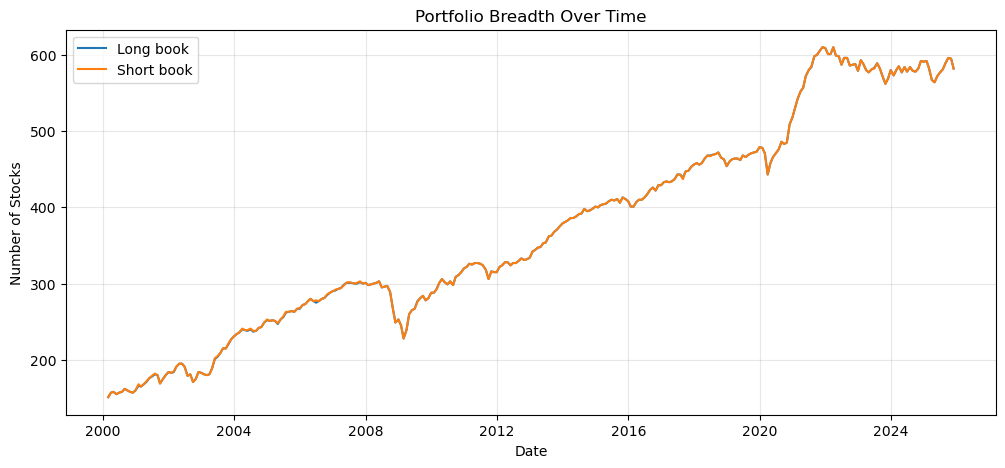

In [30]:
plt.figure(figsize=(12, 5))
plt.plot(breadth["signal_date"], breadth["n_long"], label="Long book")
plt.plot(breadth["signal_date"], breadth["n_short"], label="Short book")
plt.title("Portfolio Breadth Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Stocks")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 12. Long vs short composition

In [31]:
factor_summary_by_side = (
    weights_at_E.groupby("side")[["market_cap", "pb", "ep", "mom_1m"]]
    .mean()
)

factor_summary_by_side

,market_cap,pb,ep,mom_1m
side,,,,
long,1.708809e+09,1.270138,1.794361,0.064413
short,1.401023e+11,3895.147847,-0.193270,-0.061168


In [32]:
factor_check = (
    weights_at_E
    .groupby(["signal_date", "side"])
    .agg({
        "market_cap": "mean",
        "pb": "mean",
        "ep": "mean",
        "mom_1m": "mean"
    })
    .reset_index()
    .pivot(index="signal_date", columns="side")
)

factor_check.columns = ["_".join(col) for col in factor_check.columns]
factor_check = factor_check.reset_index()

factor_check.head()

,signal_date,market_cap_long,market_cap_short,pb_long,pb_short,ep_long,ep_short,mom_1m_long,mom_1m_short
0,2000-02-29,2.695997e+08,4.069397e+10,1.236173,113.726666,0.125489,0.017328,0.024119,0.091069
1,2000-03-31,7.623096e+08,3.158502e+10,1.231648,124.706421,0.142720,-0.000543,0.124571,-0.135650
2,2000-04-28,7.088683e+08,3.028502e+10,1.207147,92.047779,0.132133,-0.002987,0.068335,-0.181905
3,2000-05-31,7.664295e+08,3.055346e+10,1.152055,67.806449,0.129123,-0.001502,0.043591,-0.139109
4,2000-06-30,3.356585e+08,4.245185e+10,1.298341,69.309927,0.164896,0.008902,0.067201,0.015372


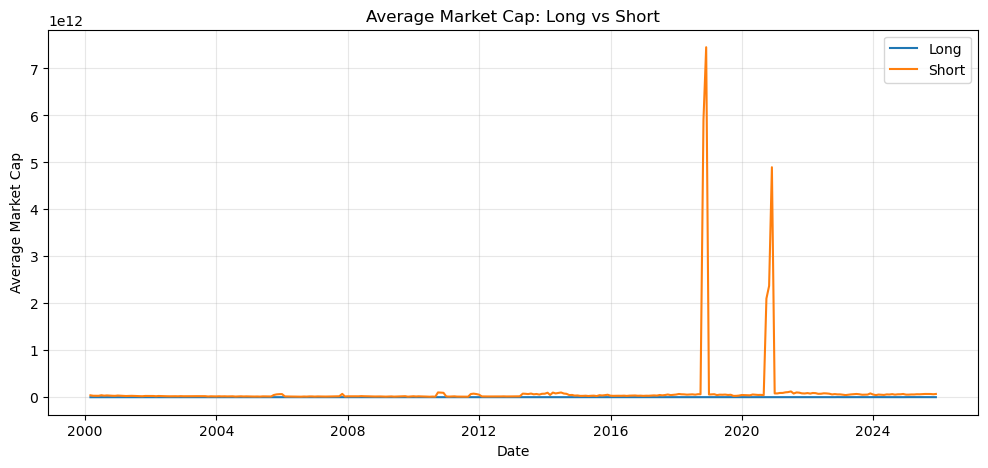

In [33]:
plt.figure(figsize=(12, 5))
plt.plot(factor_check["signal_date"], factor_check["market_cap_long"], label="Long")
plt.plot(factor_check["signal_date"], factor_check["market_cap_short"], label="Short")
plt.title("Average Market Cap: Long vs Short")
plt.xlabel("Date")
plt.ylabel("Average Market Cap")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

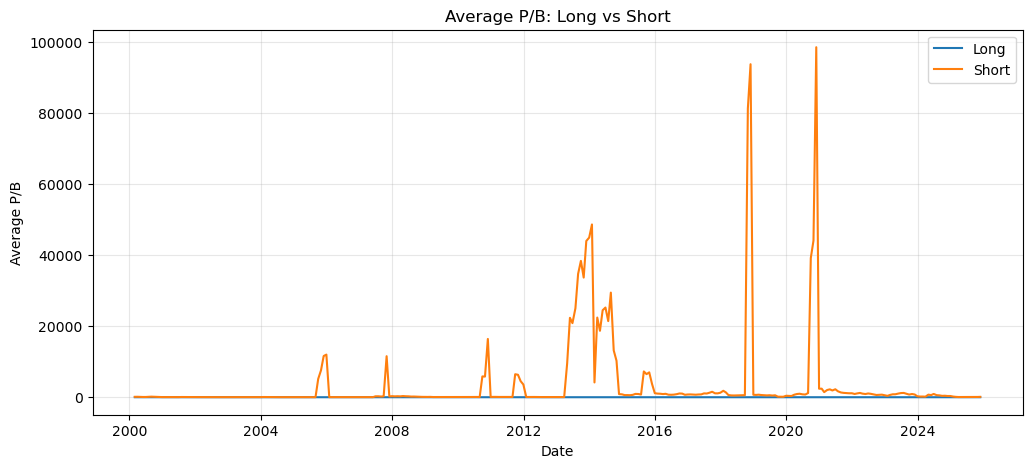

In [34]:
plt.figure(figsize=(12, 5))
plt.plot(factor_check["signal_date"], factor_check["pb_long"], label="Long")
plt.plot(factor_check["signal_date"], factor_check["pb_short"], label="Short")
plt.title("Average P/B: Long vs Short")
plt.xlabel("Date")
plt.ylabel("Average P/B")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

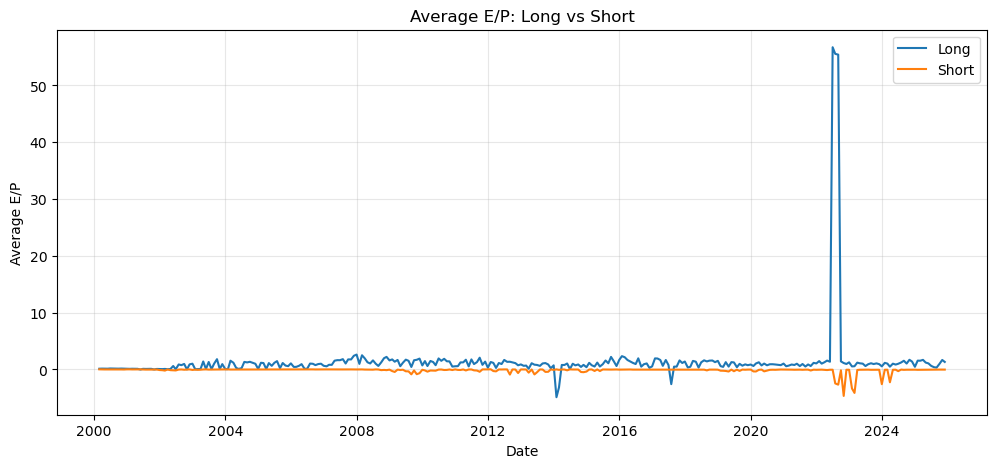

In [35]:
plt.figure(figsize=(12, 5))
plt.plot(factor_check["signal_date"], factor_check["ep_long"], label="Long")
plt.plot(factor_check["signal_date"], factor_check["ep_short"], label="Short")
plt.title("Average E/P: Long vs Short")
plt.xlabel("Date")
plt.ylabel("Average E/P")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

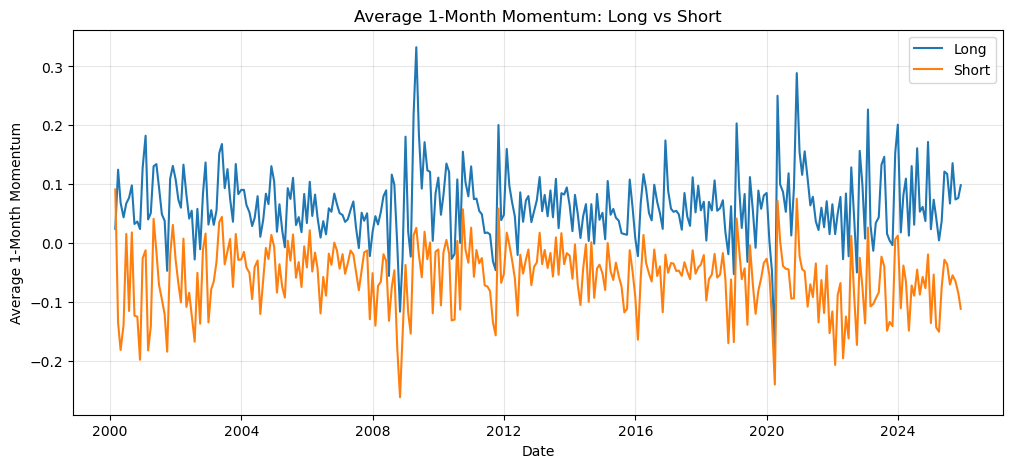

In [36]:
plt.figure(figsize=(12, 5))
plt.plot(factor_check["signal_date"], factor_check["mom_1m_long"], label="Long")
plt.plot(factor_check["signal_date"], factor_check["mom_1m_short"], label="Short")
plt.title("Average 1-Month Momentum: Long vs Short")
plt.xlabel("Date")
plt.ylabel("Average 1-Month Momentum")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 13. Benchmark comparison vs S&P 500

In [37]:
sp = yf.download(
    "^GSPC",
    start="1996-01-01",
    end="2026-01-01",
    progress=False,
    auto_adjust=False
)

sp_price = sp[("Adj Close", "^GSPC")]

sp_monthly = (
    sp_price
    .resample("ME")
    .last()
    .pct_change()
    .dropna()
    .to_frame("sp_return")
    .reset_index()
    .rename(columns={"Date": "signal_date"})
)

sp_monthly["signal_date"] = pd.to_datetime(sp_monthly["signal_date"])

sp_monthly.head()

,signal_date,sp_return
0,1996-02-29,0.006934
1,1996-03-31,0.007917
2,1996-04-30,0.013431
3,1996-05-31,0.022853
4,1996-06-30,0.002257


In [38]:
portfolio_returns["signal_date"] = pd.to_datetime(portfolio_returns["signal_date"])
portfolio_returns.head()

,signal_date,execution_date,next_execution_date,portfolio_return
0,2000-02-29,2000-03-01,2000-04-03,-0.002317
1,2000-03-31,2000-04-03,2000-05-01,0.022067
2,2000-04-28,2000-05-01,2000-06-01,0.034829
3,2000-05-31,2000-06-01,2000-07-03,-0.063132
4,2000-06-30,2000-07-03,2000-08-01,0.022538


In [39]:
portfolio_returns = portfolio_returns.sort_values("signal_date").reset_index(drop=True)
sp_monthly = sp_monthly.sort_values("signal_date").reset_index(drop=True)

In [40]:
merged = pd.merge(
    portfolio_returns,
    sp_monthly,
    on="signal_date",
    how="inner"
)

print(merged.shape)
merged.head()

(219, 5)


,signal_date,execution_date,next_execution_date,portfolio_return,sp_return
0,2000-02-29,2000-03-01,2000-04-03,-0.002317,-0.020108
1,2000-03-31,2000-04-03,2000-05-01,0.022067,0.096720
2,2000-05-31,2000-06-01,2000-07-03,-0.063132,-0.021915
3,2000-06-30,2000-07-03,2000-08-01,0.022538,0.023934
4,2000-07-31,2000-08-01,2000-09-01,-0.054294,-0.016341


In [41]:
merged["cum_carhart4"] = (1 + merged["portfolio_return"]).cumprod()
merged["cum_sp"] = (1 + merged["sp_return"]).cumprod()

merged[["signal_date", "portfolio_return", "sp_return", "cum_carhart4", "cum_sp"]].head()

,signal_date,portfolio_return,sp_return,cum_carhart4,cum_sp
0,2000-02-29,-0.002317,-0.020108,0.997683,0.979892
1,2000-03-31,0.022067,0.096720,1.019698,1.074667
2,2000-05-31,-0.063132,-0.021915,0.955323,1.051116
3,2000-06-30,0.022538,0.023934,0.976854,1.076272
4,2000-07-31,-0.054294,-0.016341,0.923816,1.058685


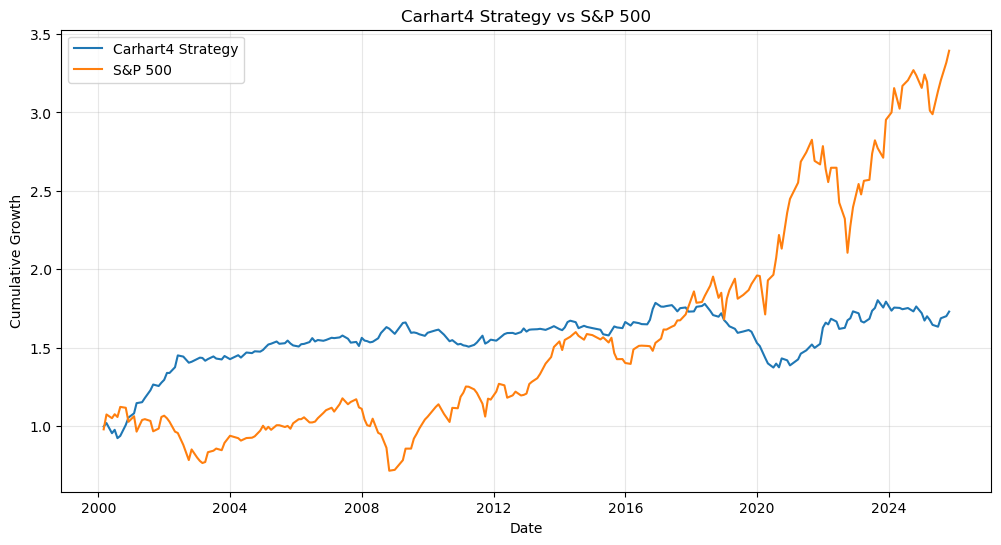

In [42]:
plt.figure(figsize=(12, 6))
plt.plot(merged["signal_date"], merged["cum_carhart4"], label="Carhart4 Strategy")
plt.plot(merged["signal_date"], merged["cum_sp"], label="S&P 500")
plt.title("Carhart4 Strategy vs S&P 500")
plt.xlabel("Date")
plt.ylabel("Cumulative Growth")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [43]:
def annualized_sharpe(monthly_returns):
    monthly_returns = monthly_returns.dropna()
    return monthly_returns.mean() / monthly_returns.std() * np.sqrt(12)

print("Carhart4 Sharpe:", annualized_sharpe(merged["portfolio_return"]))
print("S&P 500 Sharpe:", annualized_sharpe(merged["sp_return"]))

Carhart4 Sharpe: 0.4804738620707807
S&P 500 Sharpe: 0.5126480875005088


In [44]:
def max_drawdown(return_series):
    cum = (1 + return_series.fillna(0)).cumprod()
    roll_max = cum.cummax()
    drawdown = cum / roll_max - 1
    return drawdown.min()

def performance_summary(return_series):
    return pd.Series({
        "mean_monthly": return_series.mean(),
        "vol_monthly": return_series.std(),
        "ann_sharpe": annualized_sharpe(return_series),
        "positive_month_pct": (return_series > 0).mean(),
        "max_drawdown": max_drawdown(return_series),
    })

benchmark_summary = pd.DataFrame({
    "Carhart4 Strategy": performance_summary(merged["portfolio_return"]),
    "S&P 500": performance_summary(merged["sp_return"]),
}).T

benchmark_summary

,mean_monthly,vol_monthly,ann_sharpe,positive_month_pct,max_drawdown
Carhart4 Strategy,0.002694,0.019423,0.480474,0.547945,-0.230770
S&P 500,0.006593,0.044552,0.512648,0.607306,-0.391858


### 14. Turnover

In [45]:
membership_sets = (
    weights_at_E.groupby("signal_date")["ticker"]
    .apply(set)
    .reset_index(name="ticker_set")
    .sort_values("signal_date")
    .reset_index(drop=True)
)

turnover_records = []
for i in range(1, len(membership_sets)):
    prev_set = membership_sets.loc[i - 1, "ticker_set"]
    curr_set = membership_sets.loc[i, "ticker_set"]

    entered = len(curr_set - prev_set)
    exited = len(prev_set - curr_set)
    union_n = len(curr_set | prev_set)
    prev_n = len(prev_set)

    turnover_records.append({
        "signal_date": membership_sets.loc[i, "signal_date"],
        "entered": entered,
        "exited": exited,
        "turnover_rate_vs_prev": (entered + exited) / prev_n if prev_n > 0 else np.nan,
        "jaccard_similarity": len(curr_set & prev_set) / union_n if union_n > 0 else np.nan,
    })

turnover_df = pd.DataFrame(turnover_records)
turnover_df.head()

,signal_date,entered,exited,turnover_rate_vs_prev,jaccard_similarity
0,2000-03-31,133,121,0.841060,0.416092
1,2000-04-28,94,92,0.592357,0.544118
2,2000-05-31,87,93,0.569620,0.553350
3,2000-06-30,109,105,0.690323,0.489260
4,2000-07-31,116,114,0.732484,0.465116


In [46]:
turnover_df.describe()

,signal_date,entered,exited,turnover_rate_vs_prev,jaccard_similarity
count,309,309.000000,309.000000,309.000000,309.000000
mean,2013-01-28 21:49:30.873786368,274.440129,271.650485,0.737467,0.462932
min,2000-03-31 00:00:00,87.000000,91.000000,0.538588,0.362514
25%,2006-08-31 00:00:00,200.000000,198.000000,0.700758,0.442598
50%,2013-01-31 00:00:00,262.000000,257.000000,0.735521,0.462500
75%,2019-06-28 00:00:00,357.000000,352.000000,0.773810,0.483390
max,2025-11-28 00:00:00,500.000000,498.000000,0.953020,0.573472
std,NaN,100.818085,100.283239,0.064803,0.033614


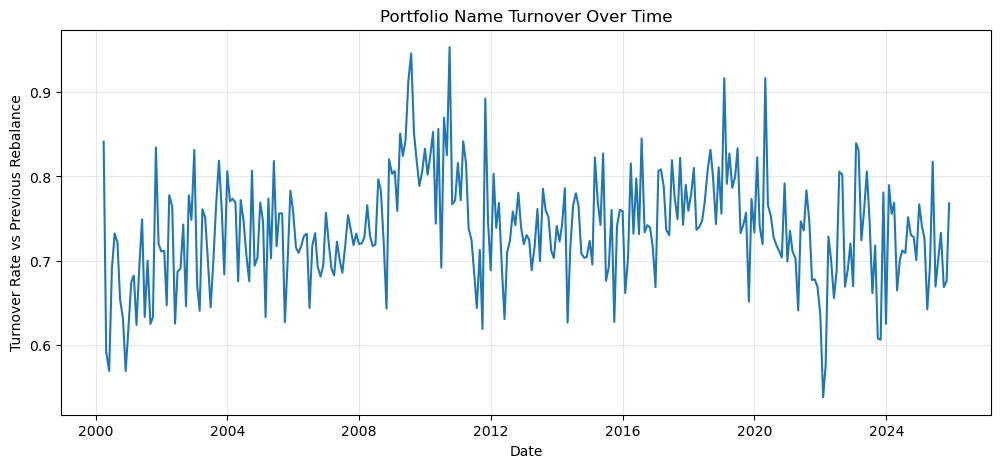

In [47]:
plt.figure(figsize=(12, 5))
plt.plot(turnover_df["signal_date"], turnover_df["turnover_rate_vs_prev"])
plt.title("Portfolio Name Turnover Over Time")
plt.xlabel("Date")
plt.ylabel("Turnover Rate vs Previous Rebalance")
plt.grid(True, alpha=0.3)
plt.show()

In [48]:
side_sets = (
    weights_at_E.groupby(["signal_date", "side"])["ticker"]
    .apply(set)
    .reset_index(name="ticker_set")
)

long_sets = (
    side_sets[side_sets["side"] == "long"][["signal_date", "ticker_set"]]
    .sort_values("signal_date")
    .reset_index(drop=True)
)

short_sets = (
    side_sets[side_sets["side"] == "short"][["signal_date", "ticker_set"]]
    .sort_values("signal_date")
    .reset_index(drop=True)
)

In [49]:
def compute_turnover_from_sets(df_sets: pd.DataFrame, label: str) -> pd.DataFrame:
    records = []
    for i in range(1, len(df_sets)):
        prev_set = df_sets.loc[i - 1, "ticker_set"]
        curr_set = df_sets.loc[i, "ticker_set"]
        prev_n = len(prev_set)
        union_n = len(curr_set | prev_set)

        records.append({
            "signal_date": df_sets.loc[i, "signal_date"],
            f"{label}_turnover": (len(curr_set - prev_set) + len(prev_set - curr_set)) / prev_n if prev_n > 0 else np.nan,
            f"{label}_jaccard": len(curr_set & prev_set) / union_n if union_n > 0 else np.nan,
        })
    return pd.DataFrame(records)

long_turnover = compute_turnover_from_sets(long_sets, "long")
short_turnover = compute_turnover_from_sets(short_sets, "short")

long_turnover.head(), short_turnover.head()

(  signal_date  long_turnover  long_jaccard
 0  2000-03-31       0.662252      0.509804
 1  2000-04-28       0.605096      0.536585
 2  2000-05-31       0.550633      0.565000
 3  2000-06-30       0.632258      0.521951
 4  2000-07-31       0.643312      0.514423,
   signal_date  short_turnover  short_jaccard
 0  2000-03-31        1.019868       0.333333
 1  2000-04-28        0.579618       0.551724
 2  2000-05-31        0.601266       0.534314
 3  2000-06-30        0.748387       0.457944
 4  2000-07-31        0.821656       0.418919)

In [50]:
turnover_side = long_turnover.merge(short_turnover, on="signal_date", how="inner")
turnover_side.head()

,signal_date,long_turnover,long_jaccard,short_turnover,short_jaccard
0,2000-03-31,0.662252,0.509804,1.019868,0.333333
1,2000-04-28,0.605096,0.536585,0.579618,0.551724
2,2000-05-31,0.550633,0.565000,0.601266,0.534314
3,2000-06-30,0.632258,0.521951,0.748387,0.457944
4,2000-07-31,0.643312,0.514423,0.821656,0.418919


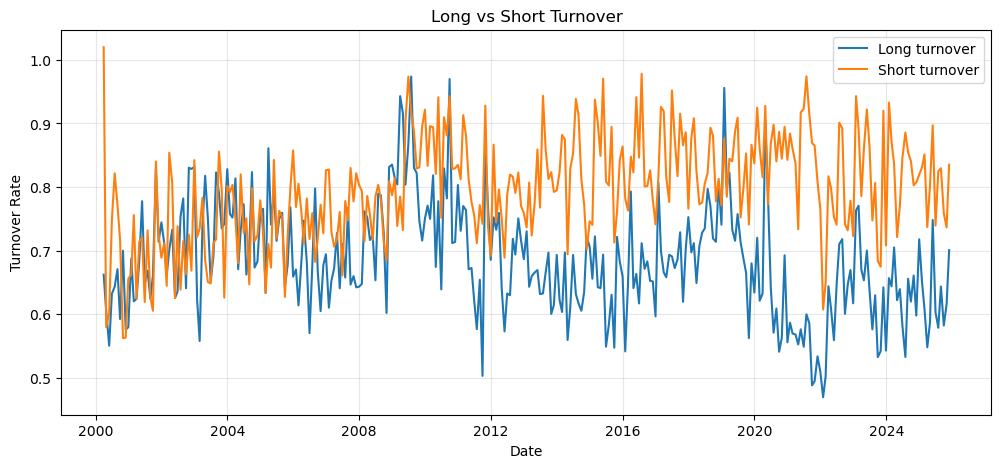

In [51]:
plt.figure(figsize=(12, 5))
plt.plot(turnover_side["signal_date"], turnover_side["long_turnover"], label="Long turnover")
plt.plot(turnover_side["signal_date"], turnover_side["short_turnover"], label="Short turnover")
plt.title("Long vs Short Turnover")
plt.xlabel("Date")
plt.ylabel("Turnover Rate")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 15. A compact text summary cell for every model

In [52]:
print("=== MODEL SUMMARY ===")
print(f"Net annualized Sharpe: {annualized_sharpe(ls_monthly['portfolio_return_rebuilt']):.4f}")
print(f"Long annualized Sharpe: {annualized_sharpe(ls_monthly['long_return']):.4f}")
print(f"Short annualized Sharpe: {annualized_sharpe(ls_monthly['short_return']):.4f}")
print(f"Long-short correlation: {ls_monthly['long_return'].corr(ls_monthly['short_return']):.4f}")
print(f"Max drawdown: {max_drawdown(ls_monthly['portfolio_return_rebuilt']):.4f}")
print(f"Average universe size: {universe_size['n_universe'].mean():.2f}")
print(f"Average long breadth: {breadth['n_long'].mean():.2f}")
print(f"Average short breadth: {breadth['n_short'].mean():.2f}")

=== MODEL SUMMARY ===
Net annualized Sharpe: 0.3622
Long annualized Sharpe: 0.6833
Short annualized Sharpe: -0.3476
Long-short correlation: -0.8203
Max drawdown: -0.2789
Average universe size: 1857.17
Average long breadth: 370.92
Average short breadth: 370.98
